# GCNII Embeddings for Contig Binning

GCNII adds initial residual connections and identity mapping to reduce oversmoothing in deeper GCNs. This notebook trains a GCNII graph autoencoder with marker cannot-link constraints before clustering.

This notebook runs the test dataset 10 times with different seeds, records all metrics for every run, prints min/max/mean/std, and plots mean metric values with standard-deviation error bars. Labels are used only after clustering to evaluate the bins. Node features use the RepBin-like representation: adjacency row + 136 TNF + coverage. The number of clusters is estimated from `contigs.fasta.markers`.

If dependencies are missing in a fresh environment, run:

```python
%pip install agtools torch scikit-learn biopython numpy pandas matplotlib scipy
```

In [1]:
from pathlib import Path
import sys

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name == 'notebooks':
    REPO_ROOT = NOTEBOOK_DIR.parent
else:
    REPO_ROOT = NOTEBOOK_DIR
sys.path.insert(0, str(REPO_ROOT / 'notebooks'))

from graph_binning_common import *

DATA_DIR = REPO_ROOT / 'tests' / 'data'
SEED = 7
N_RUNS = 10
set_seed(SEED)


In [2]:
data = load_spades_dataset(DATA_DIR)
print_dataset_summary(data)

features = data['features']
adjacency = data['adjacency']
marker_pairs = data['marker_pairs']
labels = data['labels']
label_names = data['label_names']
N_CLUSTERS = data['marker_cluster_count']
print(f'k for clustering from marker genes: {N_CLUSTERS}')
print(f'marker cannot-link pairs: {len(marker_pairs)}')
print(data['feature_names'][:3], '...', data['feature_names'][-3:])


contigs: 509
edges: 1033
features: 646 (509 adjacency + 136 TNF + coverage)
marker sets: 91
marker-derived k: 5
Acetobacter_pasteurianus: 118
Aeromonas_veronii: 72
Amycolatopsis_mediterranei: 105
Arthrobacter_arilaitensis: 195
Azorhizobium_caulinodans: 19
k for clustering from marker genes: 5
marker cannot-link pairs: 1820
['adjacency_to_node_0', 'adjacency_to_node_1', 'adjacency_to_node_2'] ... ['TGCA', 'TTAA', 'log1p_coverage_zscore']


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F

METHOD_NAME = 'GCNII'

class GCNIIEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim=96, embedding_dim=32, n_layers=6, alpha=0.1, lamda=0.5, dropout=0.25):
        super().__init__()
        self.input = nn.Linear(in_dim, hidden_dim)
        self.layers = nn.ModuleList([nn.Linear(hidden_dim, hidden_dim, bias=False) for _ in range(n_layers)])
        self.output = nn.Linear(hidden_dim, embedding_dim, bias=False)
        self.alpha = alpha
        self.lamda = lamda
        self.dropout = dropout

    def forward(self, x, adjacency):
        a_hat = normalized_adjacency(adjacency.numpy(), mode='symmetric')
        a_hat = torch.tensor(a_hat, dtype=torch.float32, device=x.device)
        h0 = F.relu(self.input(x))
        h = h0
        for layer_idx, layer in enumerate(self.layers, start=1):
            beta = np.log(self.lamda / layer_idx + 1.0)
            h_prop = (1 - self.alpha) * (a_hat @ h) + self.alpha * h0
            h = (1 - beta) * h_prop + beta * layer(h_prop)
            h = F.relu(h)
            h = F.dropout(h, p=self.dropout, training=self.training)
        z = self.output(h)
        return F.normalize(z, p=2, dim=1)

def run_once(seed):
    set_seed(seed)
    model = GCNIIEncoder(features.shape[1])
    embeddings, history = train_torch_graph_autoencoder(model, features, adjacency, marker_pairs, learning_rate=0.005)
    predictions, metrics = run_kmeans(embeddings, labels, seed=seed, n_clusters=N_CLUSTERS)
    metrics.update({'epochs': history[-1]['epoch'], 'loss': history[-1]['loss']})
    return metrics


run 01 seed=7: precision=0.9568, recall=0.8546, f1=0.9028, ari=0.7688, nmi=0.8666
run 02 seed=8: precision=0.9430, recall=0.8468, f1=0.8923, ari=0.7444, nmi=0.8271
run 03 seed=9: precision=0.9430, recall=0.8998, f1=0.9209, ari=0.8116, nmi=0.8493
run 04 seed=10: precision=0.9568, recall=0.8369, f1=0.8929, ari=0.7567, nmi=0.8611
run 05 seed=11: precision=0.9587, recall=0.8507, f1=0.9015, ari=0.7697, nmi=0.8710
run 06 seed=12: precision=0.9509, recall=0.8035, f1=0.8710, ari=0.7301, nmi=0.8395
run 07 seed=13: precision=0.9430, recall=0.8016, f1=0.8666, ari=0.7134, nmi=0.8206
run 08 seed=14: precision=0.9489, recall=0.8468, f1=0.8949, ari=0.7513, nmi=0.8419
run 09 seed=15: precision=0.9470, recall=0.8350, f1=0.8874, ari=0.7402, nmi=0.8349
run 10 seed=16: precision=0.9568, recall=0.8566, f1=0.9039, ari=0.7705, nmi=0.8671


,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,1,7,0.956778,0.854617,0.902817,0.768835,0.866639,5,5,0.819749,400,1.069543
1,2,8,0.943026,0.846758,0.892303,0.744442,0.827100,5,5,0.812943,400,1.069801
2,3,9,0.943026,0.899804,0.920908,0.811644,0.849264,5,5,0.852916,400,1.070151
3,4,10,0.956778,0.836935,0.892853,0.756671,0.861137,5,5,0.807603,400,1.069835
4,5,11,0.958743,0.850688,0.901489,0.769668,0.871031,5,5,0.817476,400,1.070099
5,6,12,0.950884,0.803536,0.871023,0.730100,0.839451,5,5,0.784726,400,1.070151
6,7,13,0.943026,0.801572,0.866564,0.713443,0.820650,5,5,0.783529,400,1.069807
7,8,14,0.948919,0.846758,0.894933,0.751305,0.841885,5,5,0.813087,400,1.069806
8,9,15,0.946955,0.834971,0.887444,0.740208,0.834938,5,5,0.805278,400,1.069820
9,10,16,0.956778,0.856582,0.903912,0.770455,0.867134,5,5,0.821156,400,1.070238


,min,max,mean,std
precision,0.943026,0.958743,0.950491,0.006403
recall,0.801572,0.899804,0.843222,0.027904
f1,0.866564,0.920908,0.893424,0.015922
ari,0.713443,0.811644,0.755677,0.026963
nmi,0.820650,0.871031,0.847923,0.017901
aligned_macro_f1,0.783529,0.852916,0.811846,0.019632


<Axes: title={'center': 'GCNII: mean metrics over 10 runs'}, ylabel='score'>

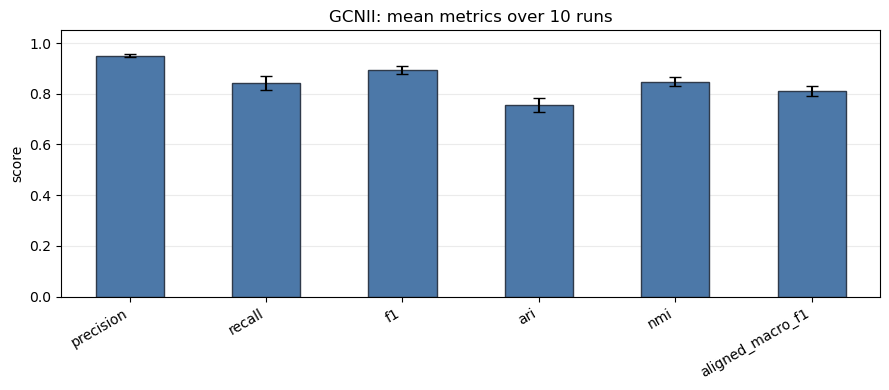

In [4]:
results = run_repeated_experiment(run_once, n_runs=N_RUNS, seed=SEED)
summary = summarize_metric_table(results)

display(results)
display(summary)
plot_metric_bars(summary, title=f'{METHOD_NAME}: mean metrics over {N_RUNS} runs')


## Assembly graph coloured by predicted bin

This plot reruns the method once on the original test graph using `SEED`, captures that method's KMeans bin assignments, and colours contigs in the igraph assembly graph by the predicted bin.

{'precision': 0.9567779960707269, 'recall': 0.8585461689587426, 'f1': 0.9050042949846485, 'ari': 0.7713345776010543, 'nmi': 0.867510902869956, 'n_bins_predicted': 5, 'n_true_bins': 5, 'aligned_macro_f1': 0.8223967641726604, 'epochs': 400, 'loss': 1.0694853067398071}
GCNII: assembly graph coloured by predicted bin
bin 0: 107 contigs
bin 1: 117 contigs
bin 2: 124 contigs
bin 3: 88 contigs
bin 4: 73 contigs


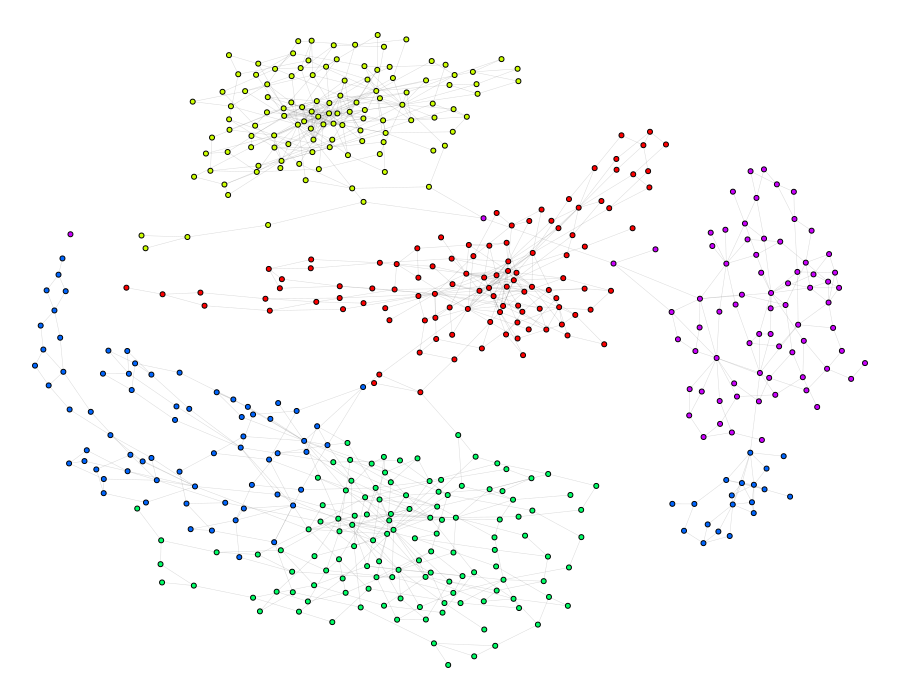

In [5]:
_visual_predictions = None
_original_run_kmeans = run_kmeans

def _capture_run_kmeans(embeddings, labels, seed=7, n_clusters=None):
    global _visual_predictions
    predictions, metrics = _original_run_kmeans(embeddings, labels, seed=seed, n_clusters=n_clusters)
    _visual_predictions = predictions
    return predictions, metrics

run_kmeans = _capture_run_kmeans
try:
    visual_metrics = run_once(SEED)
finally:
    run_kmeans = _original_run_kmeans

print(visual_metrics)
plot_assembly_graph_bins(
    data,
    bins=_visual_predictions,
    title=f'{METHOD_NAME}: assembly graph coloured by predicted bin',
)


## Graph corruption / ablation study

This section reruns the same method under five graph conditions: original assembly graph, random edge removal, random edge addition, coverage-similarity edges added, and short contigs removed. Each condition is run with the same 10 seeds, then metrics are summarized and plotted with standard-deviation error bars.

ablation: original assembly graph
ablation: random edge removal
ablation: random edge addition
ablation: coverage-similarity edges added
ablation: short contigs removed


,ablation,run,seed,precision,recall,f1,ari,nmi,n_bins_predicted,n_true_bins,aligned_macro_f1,epochs,loss
0,original assembly graph,1,7,0.954813,0.858546,0.904124,0.769696,0.861038,5,5,0.821762,400,1.069553
1,original assembly graph,2,8,0.948919,0.858546,0.901473,0.763133,0.843615,5,5,0.821730,400,1.069609
2,original assembly graph,3,9,0.944990,0.899804,0.921843,0.813992,0.855754,5,5,0.852870,400,1.070114
3,original assembly graph,4,10,0.939096,0.825147,0.878442,0.722018,0.822319,5,5,0.798747,400,1.069967
4,original assembly graph,5,11,0.956778,0.864440,0.908268,0.776979,0.869100,5,5,0.826625,400,1.070042
5,original assembly graph,6,12,0.950884,0.801572,0.869867,0.729541,0.839260,5,5,0.783427,400,1.070027
6,original assembly graph,7,13,0.954813,0.817289,0.880715,0.743222,0.852815,5,5,0.793803,400,1.069725
7,original assembly graph,8,14,0.948919,0.846758,0.894933,0.751305,0.841885,5,5,0.813087,400,1.069768
8,original assembly graph,9,15,0.925344,0.868369,0.895952,0.763463,0.822614,5,5,0.825178,400,1.069885
9,original assembly graph,10,16,0.956778,0.856582,0.903912,0.770455,0.867134,5,5,0.821156,400,1.070142


precision                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.925344  0.956778  0.948134  0.009766   
random edge removal              0.913556  0.937132  0.922004  0.008789   
random edge addition             0.888016  0.925344  0.902947  0.010649   
coverage-similarity edges added  0.829077  0.840864  0.836149  0.003728   
short contigs removed            0.911111  0.948889  0.933333  0.009827   

                                   recall                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.801572  0.899804  0.849705  0.028399   
random edge removal              0.762279  0.805501  0.785462  0.015492   
random edge addition             0.762279  0.799607  0.788409  0.013359   
coverage-similarity edges added  0.734774  0.799607  0.783104  0.018435   
short contigs removed            0.800000  0.844444  0.824000  0.011981   

                                       f1            ...       ari            \
                                      min       max  ...      mean       std   
ablation                                             ...                       
original assembly graph          0.869867  0.921843  ...  0.760380  0.026150   
random edge removal              0.831090  0.861779  ...  0.670638  0.021563   
random edge addition             0.827001  0.850215  ...  0.646225  0.012431   
coverage-similarity edges added  0.780813  0.815785  ...  0.562964  0.017048   
short contigs removed            0.851948  0.893625  ...  0.725470  0.022437   

                                      nmi                                \
                                      min       max      mean       std   
ablation                                                                  
original assembly graph          0.822319  0.869100  0.847553  0.016665   
random edge removal              0.761723  0.809391  0.781455  0.015657   
random edge addition             0.697623  0.757149  0.719093  0.015981   
coverage-similarity edges added  0.587098  0.621861  0.607425  0.010145   
short contigs removed            0.776943  0.849370  0.816205  0.018629   

                                aligned_macro_f1                                
                                             min       max      mean       std  
ablation                                                                        
original assembly graph                 0.783427  0.852870  0.815839  0.019745  
random edge removal                     0.752829  0.782968  0.769815  0.010741  
random edge addition                    0.747887  0.771731  0.761908  0.008699  
coverage-similarity edges added         0.689234  0.749575  0.731588  0.016714  
short contigs removed                   0.776897  0.809711  0.794738  0.008669  

[5 rows x 24 columns]

<Axes: title={'center': 'GCNII: graph corruption / ablation study'}, xlabel='ablation', ylabel='score'>

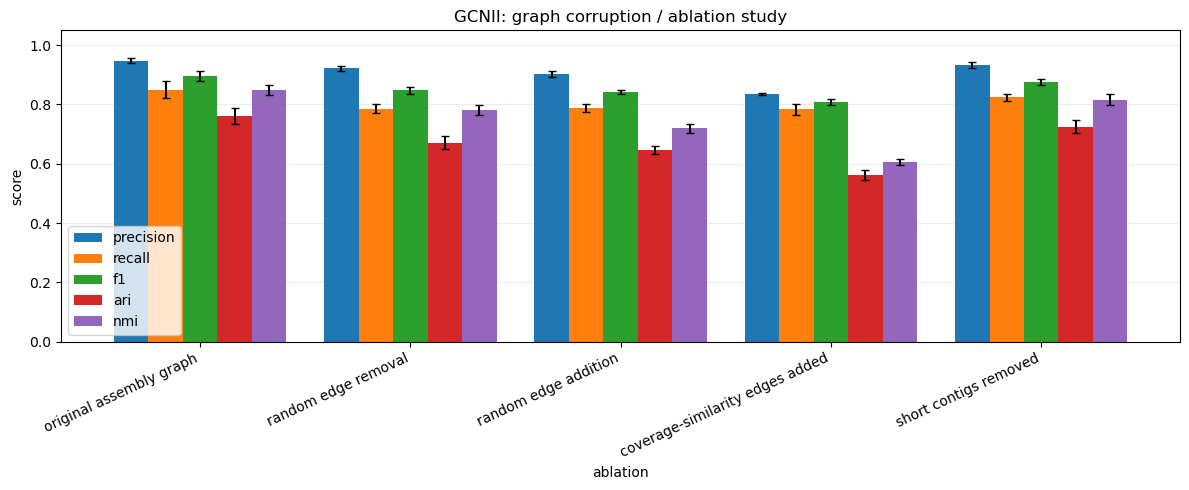

In [6]:
def run_once_ablation(seed, ablation_data):
    global features, adjacency, marker_pairs, labels, label_names, N_CLUSTERS, spectral_embeddings

    old_state = {
        'features': features,
        'adjacency': adjacency,
        'marker_pairs': marker_pairs,
        'labels': labels,
        'label_names': label_names,
        'N_CLUSTERS': N_CLUSTERS,
        'spectral_embeddings': globals().get('spectral_embeddings', None),
    }
    try:
        features = ablation_data['features']
        adjacency = ablation_data['adjacency']
        marker_pairs = ablation_data['marker_pairs']
        labels = ablation_data['labels']
        label_names = ablation_data['label_names']
        N_CLUSTERS = ablation_data['marker_cluster_count']

        # The Laplacian Eigenmaps notebook precomputes graph embeddings outside
        # run_once, so recompute them when the graph changes.
        if 'laplacian_eigenmap_embeddings' in globals():
            spectral_embeddings = laplacian_eigenmap_embeddings(adjacency, dimensions=32)

        return run_once(seed)
    finally:
        features = old_state['features']
        adjacency = old_state['adjacency']
        marker_pairs = old_state['marker_pairs']
        labels = old_state['labels']
        label_names = old_state['label_names']
        N_CLUSTERS = old_state['N_CLUSTERS']
        if old_state['spectral_embeddings'] is not None:
            spectral_embeddings = old_state['spectral_embeddings']

ablation_results, ablation_summary = run_graph_ablation_study(
    data,
    run_once_ablation,
    n_runs=N_RUNS,
    seed=SEED,
)

display(ablation_results)
display(ablation_summary)
plot_ablation_metric_bars(ablation_summary, title=f'{METHOD_NAME}: graph corruption / ablation study')
